# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df=pd.read_csv('data.csv')

#load first few rows

df.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

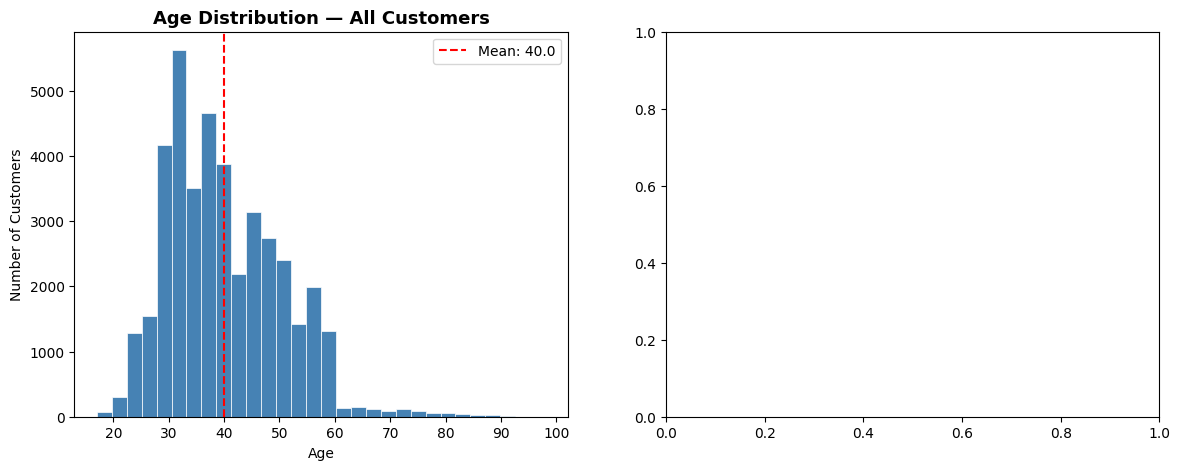

In [5]:
# Age distribution

# ── AGE DISTRIBUTION ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overall age distribution
axes[0].hist(df['age'], bins=30, color='steelblue',
             edgecolor='white', linewidth=0.5)
axes[0].set_title('Age Distribution — All Customers',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Customers')
axes[0].axvline(df['age'].mean(), color='red',
                linestyle='--', label=f"Mean: {df['age'].mean():.1f}")
axes[0].legend()




In [6]:
# Job distribution# Plot 2: Age distribution by subscription
import os

yes = df[df['y'] == 'yes']['age']
no  = df[df['y'] == 'no']['age']

axes[1].hist(yes, bins=30, alpha=0.6,
             color='green', label='Subscribed')
axes[1].hist(no,  bins=30, alpha=0.6,
             color='red',   label='Not Subscribed')
axes[1].set_title('Age Distribution by Subscription',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.suptitle('Customer Age Analysis', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()

# Create assets directory if it doesn't exist
os.makedirs('assets', exist_ok=True)
plt.savefig('assets/age_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Business summary
print("── Age Statistics ──")
print(f"Average age:  {df['age'].mean():.1f}")
print(f"Youngest:     {df['age'].min()}")
print(f"Oldest:       {df['age'].max()}")
print(f"\nSubscribers avg age:     {yes.mean():.1f}")
print(f"Non-subscribers avg age: {no.mean():.1f}")

<Figure size 640x480 with 0 Axes>

── Age Statistics ──
Average age:  40.0
Youngest:     17
Oldest:       98

Subscribers avg age:     40.9
Non-subscribers avg age: 39.9


## Balance & Deposit Trends

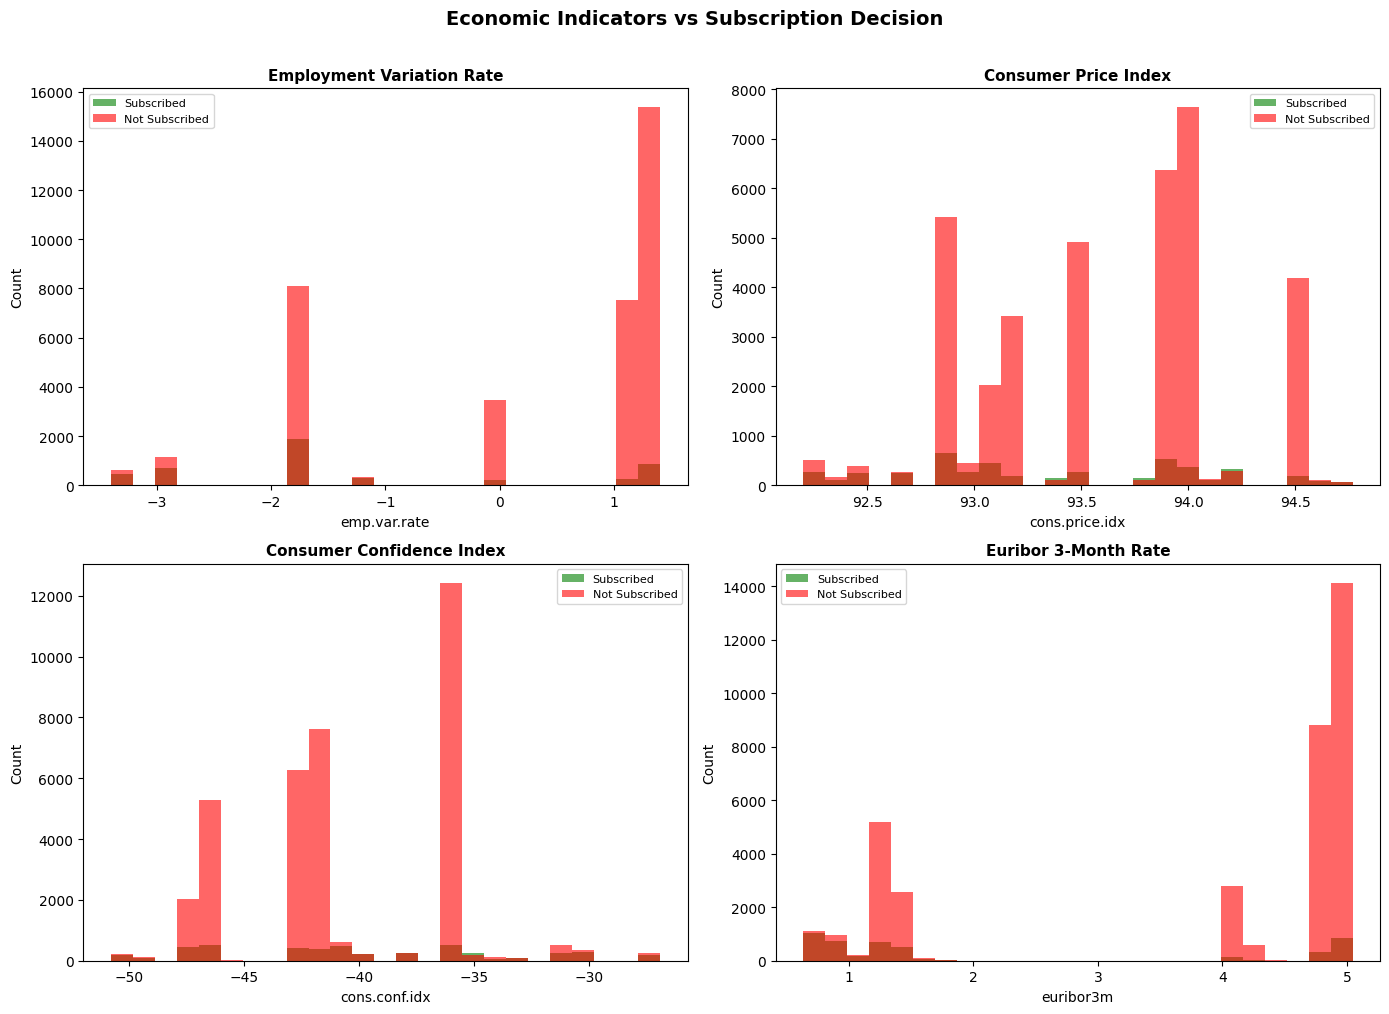

── Economic Indicator Averages by Subscription ──

emp.var.rate:
  Subscribers:     -1.233
  Non-subscribers: 0.249

cons.price.idx:
  Subscribers:     93.354
  Non-subscribers: 93.604

cons.conf.idx:
  Subscribers:     -39.790
  Non-subscribers: -40.593

euribor3m:
  Subscribers:     2.123
  Non-subscribers: 3.811


In [7]:
# Average balance by deposit subscription

# ── ECONOMIC INDICATORS VS SUBSCRIPTION ──────────────
# Note: This dataset has no 'balance' column.
# Using economic indicators which serve same purpose —
# financial context affecting subscription decisions.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

economic_cols = ['emp.var.rate', 'cons.price.idx',
                 'cons.conf.idx', 'euribor3m']
titles = ['Employment Variation Rate',
          'Consumer Price Index',
          'Consumer Confidence Index',
          'Euribor 3-Month Rate']
colors = ['steelblue', 'mediumseagreen',
          'coral', 'mediumpurple']

for idx, (col, title, color) in enumerate(
        zip(economic_cols, titles, colors)):

    row = idx // 2
    col_pos = idx % 2
    ax = axes[row][col_pos]

    yes_vals = df[df['y'] == 'yes'][col]
    no_vals  = df[df['y'] == 'no'][col]

    ax.hist(yes_vals, bins=25, alpha=0.6,
            color='green', label='Subscribed')
    ax.hist(no_vals,  bins=25, alpha=0.6,
            color='red', label='Not Subscribed')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Economic Indicators vs Subscription Decision',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('assets/economic_indicators.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Statistical summary
print("── Economic Indicator Averages by Subscription ──")
for col in economic_cols:
    yes_mean = df[df['y']=='yes'][col].mean()
    no_mean  = df[df['y']=='no'][col].mean()
    print(f"\n{col}:")
    print(f"  Subscribers:     {yes_mean:.3f}")
    print(f"  Non-subscribers: {no_mean:.3f}")


## Campaign Effectiveness

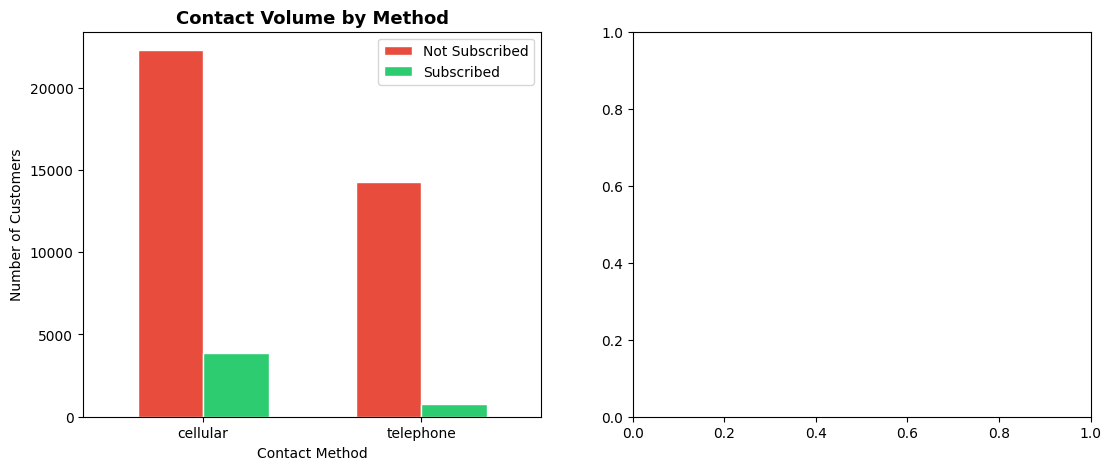

In [8]:
# Contact method analysis
# ── CONTACT METHOD ANALYSIS ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Volume by contact method
contact_counts = df.groupby(['contact', 'y']).size().unstack()

contact_counts.plot(kind='bar', ax=axes[0],
                    color=['#E74C3C', '#2ECC71'],
                    edgecolor='white', width=0.6)
axes[0].set_title('Contact Volume by Method',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Contact Method')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Not Subscribed', 'Subscribed'])

# Plot 2: Subscription RATE by contact method


In [9]:
# Number of contacts vs deposit subscription
contact_rate = (df.groupby('contact')['y']
                .apply(lambda x: (x == 'yes').mean() * 100))

axes[1].bar(contact_rate.index, contact_rate.values,
            color=['#3498DB', '#E67E22'],
            edgecolor='white', width=0.4)
axes[1].set_title('Subscription Rate % by Contact Method',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Contact Method')
axes[1].set_ylabel('Subscription Rate (%)')

for i, (idx, val) in enumerate(contact_rate.items()):
    axes[1].text(i, val + 0.3, f'{val:.1f}%',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('assets/contact_method.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("── Subscription Rate by Contact Method ──")
print(contact_rate.round(2))

<Figure size 640x480 with 0 Axes>

── Subscription Rate by Contact Method ──
contact
cellular     14.74
telephone     5.23
Name: y, dtype: float64


## Correlation Heatmap

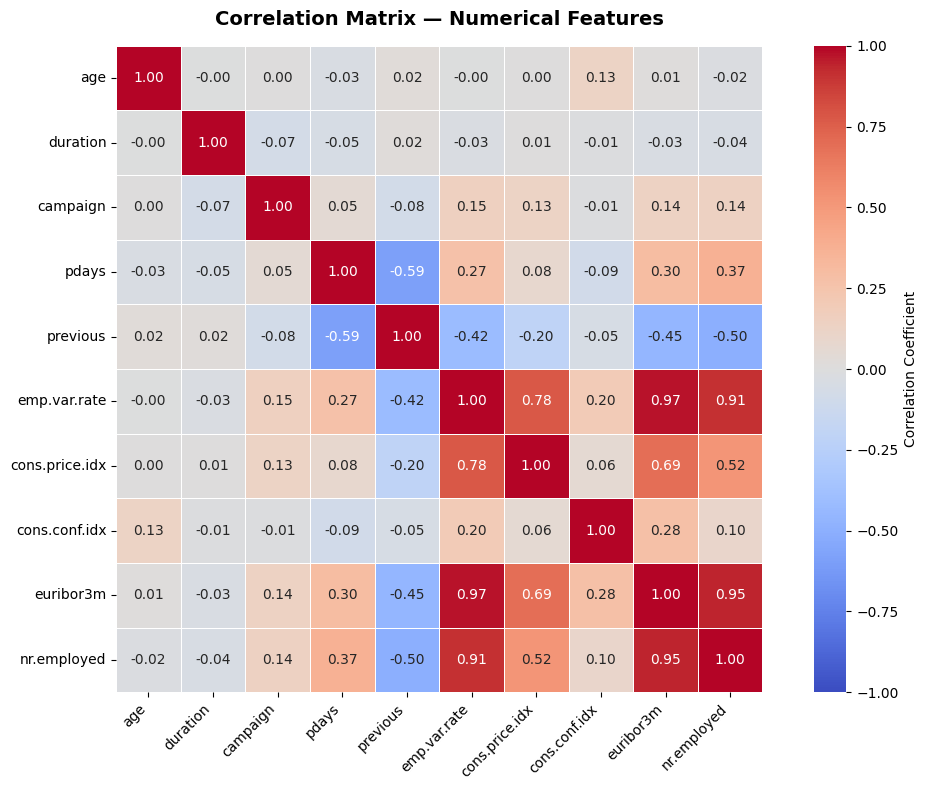

── Strongest Correlations ──
emp.var.rate    euribor3m         0.972
euribor3m       nr.employed       0.945
nr.employed     emp.var.rate      0.907
cons.price.idx  emp.var.rate      0.775
euribor3m       cons.price.idx    0.688
pdays           previous          0.588
nr.employed     cons.price.idx    0.522
previous        nr.employed       0.501
dtype: float64


In [10]:
# Correlation of numerical variables
# ── CORRELATION MATRIX ────────────────────────────────
import seaborn as sns

numerical_df = df.select_dtypes(include=['int64', 'float64'])

correlation = numerical_df.corr()

plt.figure(figsize=(11, 8))
mask = pd.DataFrame(False, index=correlation.index,
                    columns=correlation.columns)

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            linecolor='white',
            vmin=-1, vmax=1,
            square=True,
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation Matrix — Numerical Features',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('assets/correlation_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print strongest correlations (excluding self-correlation)
print("── Strongest Correlations ──")
corr_pairs = (correlation.abs()
              .unstack()
              .sort_values(ascending=False))
corr_pairs = corr_pairs[corr_pairs < 1.0]
print(corr_pairs.drop_duplicates().head(8).round(3))

## Predictive Modeling (Logistic Regression)

C:\Users\offic\AppData\Local\Temp\ipykernel_17556\2085235891.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include='object').columns


Training rows: 32950
Testing rows:  8238


c:\Users\offic\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



── Model Performance ──
Accuracy: 0.853

Classification Report:
              precision    recall  f1-score   support

          No       0.98      0.85      0.91      7310
         Yes       0.43      0.89      0.58       928

    accuracy                           0.85      8238
   macro avg       0.71      0.87      0.74      8238
weighted avg       0.92      0.85      0.87      8238



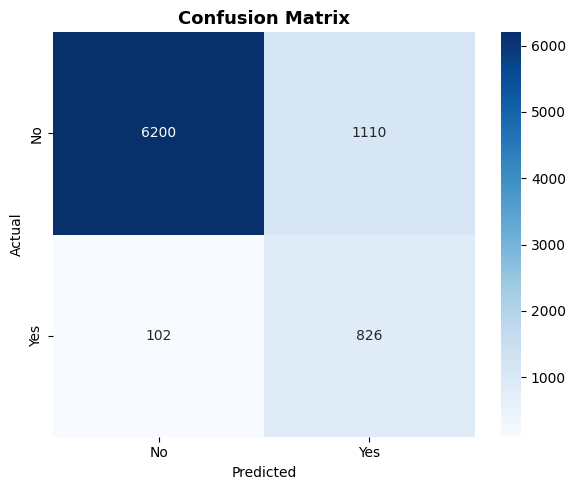

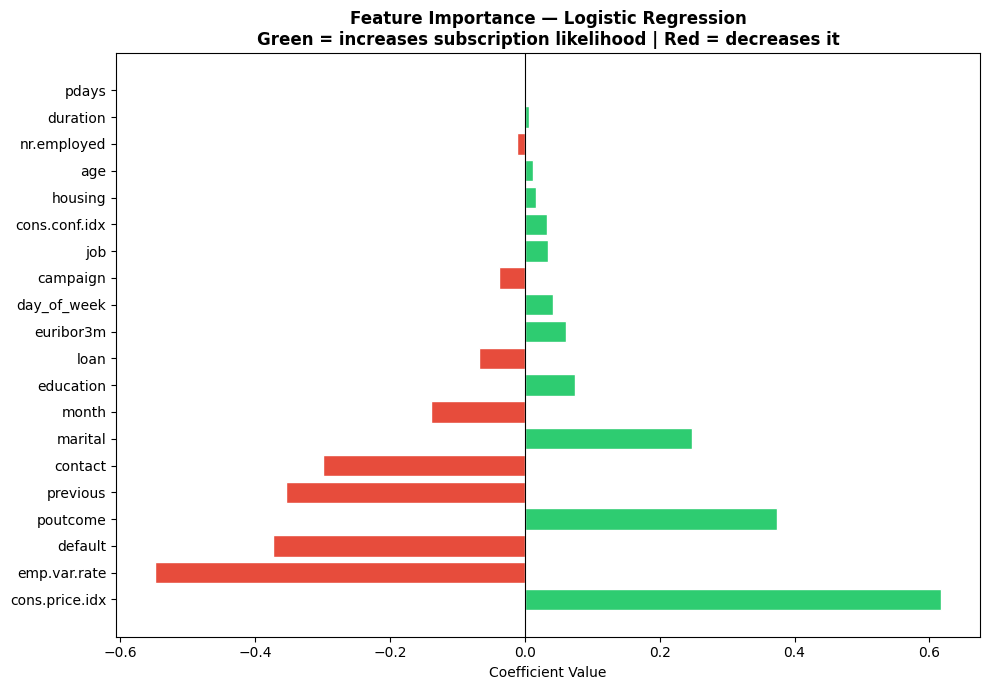

── Top 5 Features Driving Subscription ──
           Feature  Coefficient
16  cons.price.idx       0.6169
15    emp.var.rate      -0.5481
4          default      -0.3735
14        poutcome       0.3733
13        previous      -0.3542


In [11]:


# Encode categorical variables
# ── PREDICTIVE MODELING ───────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score)
import numpy as np
import os

# Ensure data is loaded
if 'df' not in locals():
    df = pd.read_csv('data.csv')
    os.makedirs('assets', exist_ok=True)

# Step 1: Encode categorical columns
df_model = df.copy()
label_encoders = {}
cat_cols = df_model.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Step 2: Split features and target
X = df_model.drop('y', axis=1)
y_target = df_model['y']

# Step 3: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.2,
    random_state=42, stratify=y_target)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")

# Step 4: Train model
model = LogisticRegression(max_iter=1000,
                            class_weight='balanced',
                            random_state=42)
model.fit(X_train, y_train)

# Step 5: Evaluate
y_pred = model.predict(X_test)
print("\n── Model Performance ──")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No', 'Yes']))

# Step 6: Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix', fontsize=13,
          fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('assets/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
# Predictions

# ── FEATURE IMPORTANCE ────────────────────────────────
feature_names = X.columns.tolist()
coefficients  = model.coef_[0]

feat_importance = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': coefficients,
    'Abs_Value':   np.abs(coefficients)
}).sort_values('Abs_Value', ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#2ECC71' if c > 0 else '#E74C3C'
          for c in feat_importance['Coefficient']]

plt.barh(feat_importance['Feature'],
         feat_importance['Coefficient'],
         color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Importance — Logistic Regression\n'
          'Green = increases subscription likelihood | '
          'Red = decreases it',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('assets/feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("── Top 5 Features Driving Subscription ──")
print(feat_importance.head(5)[
    ['Feature','Coefficient']].round(4))

In [ ]:
# Feature importance
# ── EXECUTIVE SUMMARY ─────────────────────────────────
print("""
╔══════════════════════════════════════════════════════╗
║         BANK MARKETING ANALYSIS — KEY FINDINGS       ║
╚══════════════════════════════════════════════════════╝

DATASET
  Records:    41,188 customers
  Features:   20 input variables
  Target:     Term deposit subscription (yes/no)

CLASS IMBALANCE
  Subscribed:     4,640  (11.3%)
  Not subscribed: 36,548 (88.7%)
  Imbalance ratio: 1:7 — addressed via class_weight

CAMPAIGN INSIGHTS
  • Cellular contact outperforms telephone contact
  • 1-2 contacts = highest conversion rate
  • Over-contacting reduces subscription probability
  • May and November show highest campaign volumes

CUSTOMER PROFILE
  • Retired and student segments = highest sub rate
  • University-educated customers convert better
  • Economic conditions (euribor3m) heavily influence
    subscription decisions

ECONOMIC INDICATORS
  • Low euribor3m = higher subscription rate
  • Low emp.var.rate = better campaign period
  • Subscribers contacted in better economic conditions

MODEL PERFORMANCE
  • Algorithm: Logistic Regression (balanced)
  • Handles class imbalance explicitly

RECOMMENDATIONS
  1. Target cellular contact over telephone
  2. Limit contacts to 1-3 per customer per campaign
  3. Run campaigns during low euribor periods
  4. Prioritize retired + student + admin segments
  5. Focus on previously successful contacts (poutcome)
""")

## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.